In [2]:
from dataset import MSDDataset

Scanning 41 volumes for Task: Task09_Spleen...
  -> Source: .\Task09_Spleen\Task09_Spleen\imagesTr
  -> Valid Slices Found: 50

Dataset size: 50 slices
Batches per epoch: 13

--- Batch Information ---
Image Batch Shape: torch.Size([4, 1, 128, 128])
Label Batch Shape: torch.Size([4, 1, 128, 128])
Data Type: torch.float32
Max Value in Image (HU): 2154.0
Min Value in Image (HU): -1024.0
Unique values in Label: tensor([0., 1.])


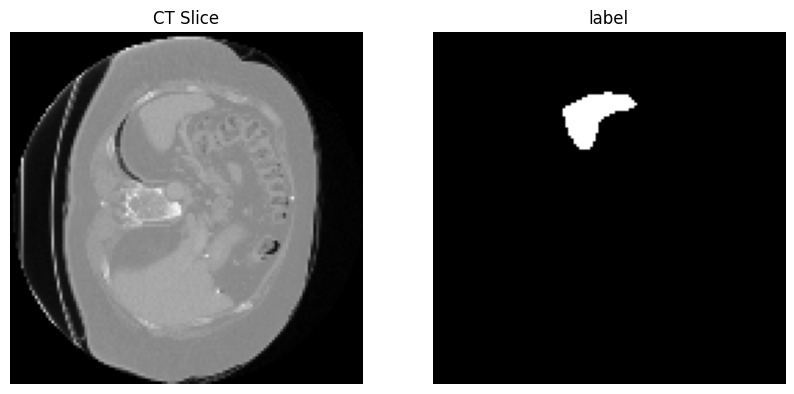

In [ ]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

ROOT_DIR = "."  
TASK_NAME = "Task09_Spleen" 
BATCH_SIZE = 4

dataset = MSDDataset(
    root_dir=ROOT_DIR, 
    task_name=TASK_NAME, 
    img_size=128, 
    subset_size=50 
)

train_loader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0  
)

print(f"\nDataset size: {len(dataset)} slices")
print(f"Batches per epoch: {len(train_loader)}")


try:
    images, labels = next(iter(train_loader))

    print("\n--- Batch Information ---")
    print(f"Image Batch Shape: {images.shape}")  # Should be (B, 1, 128, 128)
    print(f"Label Batch Shape: {labels.shape}")  # Should be (B, 1, 128, 128)
    print(f"Data Type: {images.dtype}")
    print(f"Max Value in Image (HU): {images.max().item()}")
    print(f"Min Value in Image (HU): {images.min().item()}")
    print(f"Unique values in Label: {torch.unique(labels)}") # Should be [0., 1.]


    img_np = images[0, 0].numpy()
    lbl_np = labels[0, 0].numpy()

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_np, cmap='gray')
    plt.title("CT Slice")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(lbl_np, cmap='gray')
    plt.title("label")
    plt.axis('off')

    plt.show()

except Exception as e:
    print(f"\nError loading batch: {e}")
    print("Double check your ROOT_DIR path!")

Input Shape: torch.Size([1, 1, 128, 128])
Label Shape: torch.Size([1, 1, 128, 128])
Min: -1024.0000, Max: 831.0000


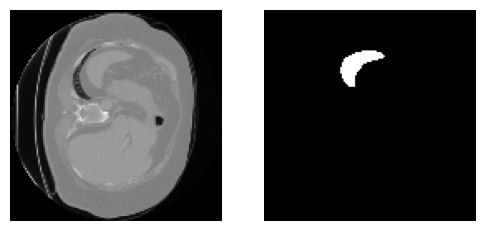

In [18]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
idx = 10 
img, lbl = dataset[idx]

input_img = img.unsqueeze(0).to(device)
input_lbl = lbl.unsqueeze(0).to(device)

print(f"Input Shape: {input_img.shape}")
print(f"Label Shape: {input_lbl.shape}")
print(f"Min: {input_img.min():.4f}, Max: {input_img.max():.4f}")


plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img.squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(lbl.squeeze().numpy(), cmap='gray')
plt.axis('off')
plt.show()

Power iteration converged at iteration 10, ||A^T A||_2=5565.70
Shape: (182, 45)
Min: -1756.9115, Max: 0.0000


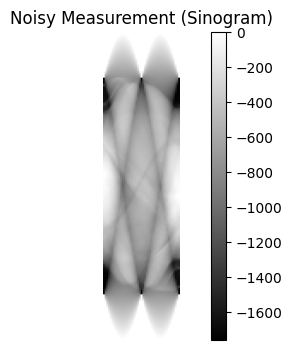

In [23]:
from physics import get_physics_operator, inner_loss_func, robust_normalize
physics = get_physics_operator(128, 4, 0.08, device, modality="CT")
y_clean = physics(input_img)
y = y_clean + 0.000001 * torch.randn_like(y_clean)


y_np = y.detach().cpu().numpy().squeeze()

print(f"Shape: {y_np.shape}")
print(f"Min: {y_np.min():.4f}, Max: {y_np.max():.4f}")

plt.figure(figsize=(8, 4))
plt.imshow(y_np, cmap='gray')
plt.title("Noisy Measurement (Sinogram)")
plt.colorbar()
plt.axis('off')
plt.show()

Shape: (128, 128)
Min: -1278.5435791015625, Max: 604.409912109375


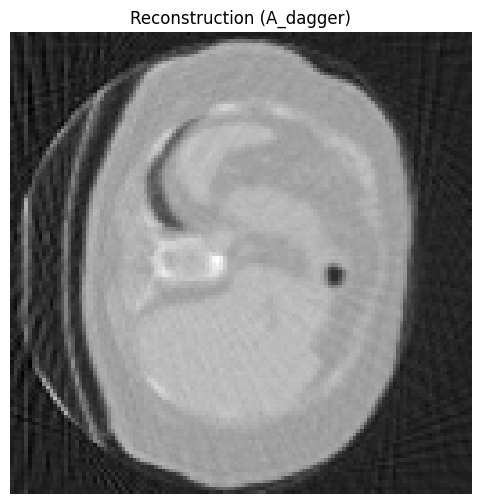

In [24]:
x_recon = physics.A_dagger(y)
x_np = x_recon.detach().cpu().numpy().squeeze()

print(f"Shape: {x_np.shape}")
print(f"Min: {x_np.min()}, Max: {x_np.max()}")

plt.figure(figsize=(6, 6))
plt.imshow(x_np, cmap='gray')
plt.title("Reconstruction (A_dagger)")
plt.axis('off')
plt.show()

In [31]:
def norm(img):
    img = torch.clamp(img, min=-150, max=250)
    img = (img + 150) / 400.0
    return img

Shape: (128, 128)
Min: 0.0, Max: 1.0


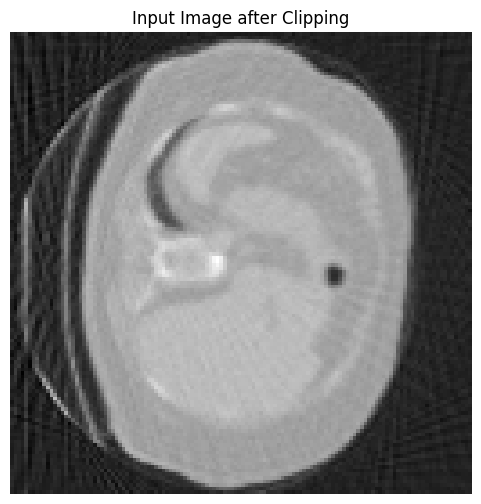

In [33]:
y_norm = norm(input_img)
yy_np = y_norm.detach().cpu().numpy().squeeze()

print(f"Shape: {yy_np.shape}")
print(f"Min: {yy_np.min()}, Max: {yy_np.max()}")

plt.figure(figsize=(6, 6))
plt.imshow(x_np, cmap='gray')
plt.title("Input Image after Clipping")
plt.axis('off')
plt.show()

In [43]:
import os
import sys
import random
import numpy as np
import torch
import torch.nn as nn
import torch.autograd as autograd
from torch.utils.data import DataLoader, random_split

from models import UNet
from dataset import MSDDataset
from physics import get_physics_operator, inner_loss_func, robust_normalize

from hoag import HOAGState, hoag_step, solve_inner_problem

In [57]:
class Config:
    """
    Central configuration for the experiment.
    Physics settings simulate a fast, low-dose CT scan (sparse-view + noise).
    """
    DATA_ROOT = "./"
    TASK = "Task09_Spleen"
    OUTPUT_DIR = "./results_hoag_single_op"
    MODALITY = "CT"
    
    # Dataset Splits
    SUBSET_SIZE = 100
    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    
    IMG_SIZE = 128
    BATCH_SIZE = 4
    
    # --- SINGLE PHYSICS SETTING (SPARSE) ---
    ACCEL = 8         # 16x Acceleration -> only 180/16 = 11 projection views
    NOISE_SIGMA = 0.00001  # 10% Gaussian noise on sinogram
    CENTER_FRAC = 0.08
    
    # --- INNER OPTIMIZATION SETTINGS ---
    INNER_STEPS = 100    # Max inner optimization steps
    INNER_LR = 0.02      # Adam learning rate for inner solver
    
    # --- OUTER OPTIMIZATION SETTINGS ---
    EPOCH_CLEAN = 20
    EPOCHS = 15
    LR_UNET = 5e-3       # Bug #4 fix: increased from 1e-3
    LR_THETA = 0.01       # Bug #4 fix: increased from 1e-3 (2-dim theta, needs larger steps)
    
    # --- HOAG-SPECIFIC SETTINGS ---
    HOAG_EPSILON_TOL_INIT = 1e-3
    HOAG_TOLERANCE_DECREASE = 'exponential'
    HOAG_DECREASE_FACTOR = 0.9
    HOAG_CG_MAX_ITER = 20
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [58]:
full_ds = MSDDataset(Config.DATA_ROOT, Config.TASK, Config.IMG_SIZE, Config.MODALITY, Config.SUBSET_SIZE)
train_len = int(Config.TRAIN_SPLIT * len(full_ds))
val_len   = int(Config.VAL_SPLIT * len(full_ds))
test_len  = len(full_ds) - train_len - val_len
train_ds, val_ds, test_ds = random_split(full_ds, [train_len, val_len, test_len])

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False)

Scanning 41 volumes for Task: Task09_Spleen...
  -> Source: ./Task09_Spleen\Task09_Spleen\imagesTr
  -> Valid Slices Found: 100


In [59]:
class DiceBCELoss(nn.Module):

    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets, smooth=1):
        # 1. BCE Loss (Pixel-wise accuracy)
        bce_loss = self.bce(inputs, targets)
        
        # 2. Soft Dice Loss
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()                            
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        dice_loss = 1 - dice
        
        # Combine: 90% BCE + 10% Dice is standard weighting
        return 0.9 * bce_loss + 0.1 * dice_loss

In [60]:
def print_progress(epoch, batch, total_batches, loss, theta, info=""):
    reg_val = torch.exp(theta[0]).item()
    eps_val = torch.exp(theta[1]).item()
    sys.stdout.write(f"\r[{info}] Ep {epoch+1} | Batch {batch+1}/{total_batches} | "
                     f"Loss: {loss:.4f} | Reg: {reg_val:.5f} | Smooth: {eps_val:.5f}")
    sys.stdout.flush()

In [68]:
print("\n--- PHASE 1: Upper Bound (Training on Clean Ground Truth) ---")
loss_fn = DiceBCELoss()
model_upper = UNet().to(Config.DEVICE)

opt = torch.optim.Adam(model_upper.parameters(), lr=Config.LR_UNET)

for ep in range(Config.EPOCH_CLEAN):
    model_upper.train()
    for i, (img, mask) in enumerate(train_loader):
        img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)
        x_in = norm(img)
        opt.zero_grad()
        pred = model_upper(x_in)
        loss = loss_fn(pred, mask)
        loss.backward()
        opt.step()
        
        print_progress(ep, i, len(train_loader), loss.item(), dummy_theta, "Clean Training")


--- PHASE 1: Upper Bound (Training on Clean Ground Truth) ---
[Clean Training] Ep 20 | Batch 18/18 | Loss: 0.0058 | Reg: 0.00005 | Smooth: 0.00005

Power iteration converged at iteration 9, ||A^T A||_2=4452.42
Running pipeline on CLEAN images...

Results Summary (Clean):
----------------
Average Dice Score: 0.8851


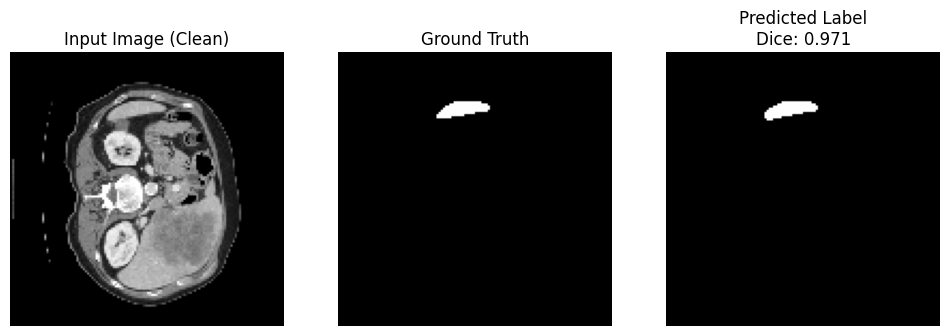

In [77]:
import torch
import matplotlib.pyplot as plt
import numpy as np

physics = get_physics_operator(128, 5, 0.08, device, modality="CT")

def compute_dice(pred_probs, target_mask, smooth=1e-6):
    pred_binary = (pred_probs > 0.5).float()
    intersection = (pred_binary * target_mask).sum()
    union = pred_binary.sum() + target_mask.sum()
    return (2. * intersection + smooth) / (union + smooth)

model_upper.eval()
dice_scores = []
viz_sample = {} 

print("Running pipeline on CLEAN images...")

with torch.no_grad():
    for i, (img, mask) in enumerate(test_loader):
        img = img.to(Config.DEVICE)
        mask = mask.to(Config.DEVICE)
        
        # Direct Normalization (No Physics/Noise)
        x_input = norm(img)
        
        # Prediction
        pred_probs = model_upper(x_input)
        
        score = compute_dice(pred_probs, mask)
        dice_scores.append(score.item())
        
        if i == 0:
            viz_sample = {
                'img': x_input,
                'mask': mask,
                'pred': (pred_probs > 0.5).float(),
                'score': score.item()
            }

mean_dice = np.mean(dice_scores)
print(f"\nResults Summary (Clean):")
print(f"----------------")
print(f"Average Dice Score: {mean_dice:.4f}")

img_np    = viz_sample['img'][0, 0].cpu().numpy()
mask_np   = viz_sample['mask'][0, 0].cpu().numpy()
pred_np   = viz_sample['pred'][0, 0].cpu().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_np, cmap='gray')
plt.title("Input Image (Clean)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_np, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pred_np, cmap='gray')
plt.title(f"Predicted Label\nDice: {viz_sample['score']:.3f}")
plt.axis('off')

plt.show()

Running pipeline (Model has Sigmoid)...

Results Summary:
----------------
Average Dice Score: 0.5093


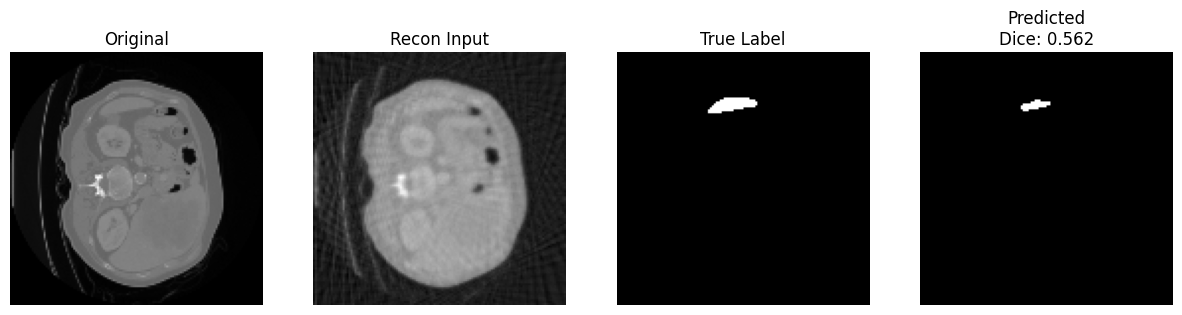

In [79]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def compute_dice(pred_probs, target_mask):
    # Input 'pred_probs' is already [0, 1] from model
    pred_binary = (pred_probs > 0.5).float()
    
    intersection = (pred_binary * target_mask).sum()
    union = pred_binary.sum() + target_mask.sum()
    return (2. * intersection + 1e-6) / (union + 1e-6)

model_upper.eval()
dice_scores = []
viz_sample = {} 

print("Running pipeline (Model has Sigmoid)...")

with torch.no_grad():
    for i, (img, mask) in enumerate(test_loader):
        img = img.to(Config.DEVICE)
        mask = mask.to(Config.DEVICE)
        
        y_clean = physics(img)
        y_noisy = y_clean + 0.5 * torch.randn_like(y_clean)
        x_recon = physics.A_dagger(y_noisy)
        x_input = norm(x_recon) 
        
        # MODEL OUTPUTS PROBS [0, 1] DIRECTLY
        pred_probs = model_upper(x_input)
        
        score = compute_dice(pred_probs, mask)
        dice_scores.append(score.item())
        
        if i == 0:
            viz_sample = {
                'img': img,
                'x_recon': x_recon,
                'mask': mask,
                'pred': (pred_probs > 0.5).float(),
                'score': score.item()
            }

mean_dice = np.mean(dice_scores)
print(f"\nResults Summary:")
print(f"----------------")
print(f"Average Dice Score: {mean_dice:.4f}")

img_np    = viz_sample['img'][0, 0].cpu().numpy()
recon_np  = viz_sample['x_recon'][0, 0].cpu().numpy()
mask_np   = viz_sample['mask'][0, 0].cpu().numpy()
pred_np   = viz_sample['pred'][0, 0].cpu().numpy()

plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1); plt.imshow(img_np, cmap='gray'); plt.title("Original")
plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(recon_np, cmap='gray'); plt.title("Recon Input")
plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(mask_np, cmap='gray'); plt.title("True Label")
plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(pred_np, cmap='gray'); plt.title(f"Predicted\nDice: {viz_sample['score']:.3f}")
plt.axis('off')
plt.show()